<a href="https://colab.research.google.com/github/Nidhi317/ML_project/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('/content/final_dataset.csv')
df = df.sample(n=9000, random_state=42)
df.head()

,leagueId,queueType,tier,rank,summonerId,summonerName.x,leaguePoints,wins,losses,veteran,...,towerKills,inhibitorKills.y,baronKills,dragonKills,vilemawKills,riftHeraldKills,dominionVictoryScore,championId,spell1Id,spell2Id
146483,34a5ea4b-9e07-47ea-8614-88c2f805374a,RANKED_SOLO_5x5,PLATINUM,I,_FNQFXikNsIlkNRjT12kukK8WDL4WAFhEgF3u9SRBd4-pA,VICK TIRO CERTO,0,130,136,False,...,10,2,1,3,0,2,0,61,4,14
51340,b6839329-6065-4c07-9d8d-e949f34eb2b1,RANKED_SOLO_5x5,DIAMOND,IV,96b7WmM7CJRUZVp_qXziu8S3ouuWrrWCAaoo27j--qPx8g,FLS Boto,0,299,281,True,...,0,0,0,0,0,0,0,64,4,11
66703,1d838ba0-04ea-440c-8912-3ace747b9863,RANKED_SOLO_5x5,GOLD,I,mOG_D43-2aTQCgR5JuFbcDB5Zkh_6LVep4G3LWvnMJiC,Vigário,100,129,130,False,...,9,2,1,3,0,0,0,64,4,11
114495,c67208b7-e871-403c-909a-953e82c5f908,RANKED_SOLO_5x5,DIAMOND,IV,SOtzqbbd9xrFTRjK6wyeovJnuZ2YEyegAa1wRXJRqFvjyFI,Heädshot,0,291,287,False,...,9,2,1,3,0,0,0,51,7,4
175094,069e3e2b-6392-45aa-8afa-29783baebd8f,RANKED_SOLO_5x5,DIAMOND,I,OviO9KTNxD-YnaPue0nwSdRVOoXweinrIorePfGDL5XUgQ,balby,100,381,372,False,...,4,0,0,1,0,1,0,235,4,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 146483 to 57574
Columns: 159 entries, leagueId to spell2Id
dtypes: bool(15), float64(13), int64(114), object(17)
memory usage: 10.1+ MB


In [ ]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 leagueId                0
queueType               0
tier                    0
rank                    0
summonerId              0
                       ..
riftHeraldKills         0
dominionVictoryScore    0
championId              0
spell1Id                0
spell2Id                0
Length: 159, dtype: int64


In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns

# Fill numeric with mean
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Verify again
print("\nAfter handling missing values:\n", df.isnull().sum())


After handling missing values:
 leagueId                0
queueType               0
tier                    0
rank                    0
summonerId              0
                       ..
riftHeraldKills         0
dominionVictoryScore    0
championId              0
spell1Id                0
spell2Id                0
Length: 159, dtype: int64


In [ ]:
bool_cols = df.select_dtypes(include=['bool']).columns

df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
df = df.drop(['wins', 'losses'], axis=1, errors='ignore')
X = df.drop('firstBloodKill', axis=1)
y = df['firstBloodKill']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,shuffle=True, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    return fpr, tpr, auc

In [ ]:
log_model = LogisticRegression(max_iter=1000)
svm_model = SVC(probability=True)
rf_model = RandomForestClassifier()

log_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier()


===== Logistic Regression =====
Accuracy: 0.9122222222222223
Precision: 0.574468085106383
Recall: 0.313953488372093
F1 Score: 0.40601503759398494


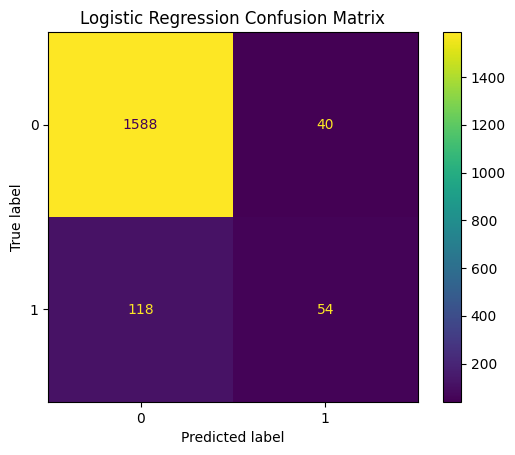


===== SVM =====
Accuracy: 0.9044444444444445
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


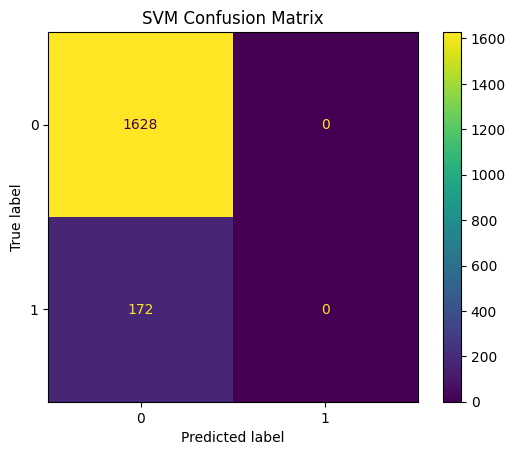


===== Random Forest =====
Accuracy: 0.905
Precision: 0.6
Recall: 0.01744186046511628
F1 Score: 0.03389830508474576


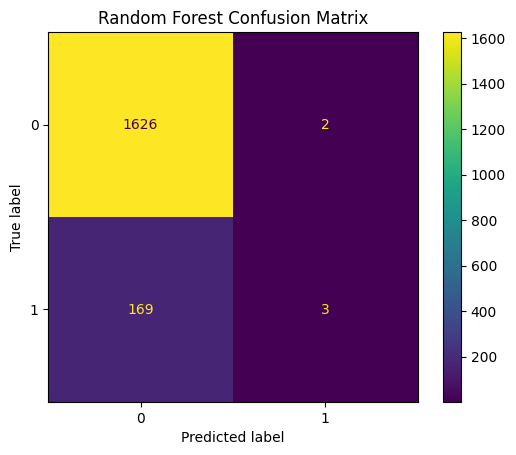

In [ ]:
roc_results = {}

roc_results['Logistic'] = evaluate_model(log_model, X_test_scaled, y_test, "Logistic Regression")
roc_results['SVM'] = evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
roc_results['Random Forest'] = evaluate_model(rf_model, X_test, y_test, "Random Forest")

In [ ]:
# Logistic Regression
log_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000), log_params, cv=3, n_jobs=-1)
log_grid.fit(X_train_scaled, y_train)


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']})

In [ ]:
svm_model = SVC(kernel='linear', C=1, probability=True)
svm_model.fit(X_train_scaled, y_train)

SVC(C=1, kernel='linear', probability=True)

In [ ]:
# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [ ]:
print("\nBest Params:")
print("Logistic:", log_grid.best_params_)
print("SVM: {'kernel': 'linear', 'C': 1}")
print("RF:", rf_grid.best_params_)


Best Params:
Logistic: {'C': 0.01, 'solver': 'liblinear'}
SVM: {'kernel': 'linear', 'C': 1}
RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}



===== Tuned Logistic =====
Accuracy: 0.9088888888888889
Precision: 0.6052631578947368
Recall: 0.13372093023255813
F1 Score: 0.21904761904761905


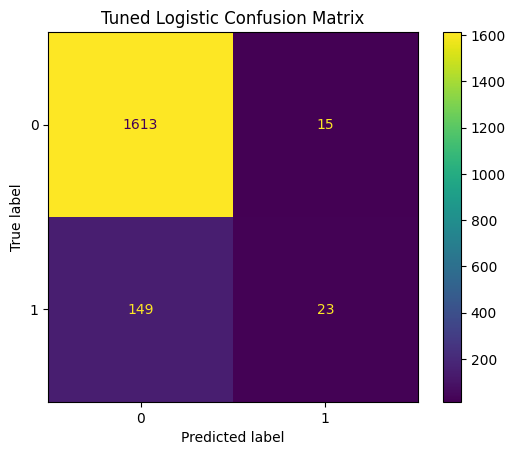


===== Tuned SVM =====
Accuracy: 0.9038888888888889
Precision: 0.3333333333333333
Recall: 0.005813953488372093
F1 Score: 0.011428571428571429


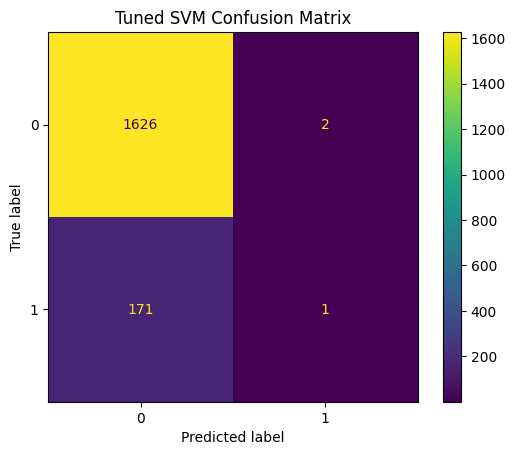


===== Tuned RF =====
Accuracy: 0.9066666666666666
Precision: 1.0
Recall: 0.023255813953488372
F1 Score: 0.045454545454545456


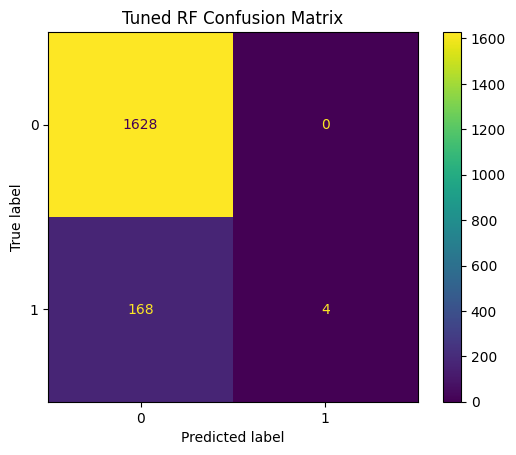

In [ ]:
roc_results_tuned = {}

roc_results_tuned['Logistic'] = evaluate_model(
    log_grid.best_estimator_, X_test_scaled, y_test, "Tuned Logistic"
)

roc_results_tuned['SVM'] = evaluate_model(
    svm_model, X_test_scaled, y_test, "Tuned SVM"
)

roc_results_tuned['Random Forest'] = evaluate_model(
    rf_grid.best_estimator_, X_test, y_test, "Tuned RF"
)

In [ ]:
print("\nCross Validation Scores:")

models = {
    "Logistic": log_grid.best_estimator_,
    "SVM": svm_model,
    "RF": rf_grid.best_estimator_
}

cv_scores = {}

for name, model in models.items():
    if name == "RF":
        scores = cross_val_score(model, X, y, cv=3, n_jobs=-1)
    else:
        scores = cross_val_score(model, scaler.fit_transform(X), y, cv=3, n_jobs=-1)

    cv_scores[name] = scores.mean()
    print(f"{name} CV Accuracy: {scores.mean():.4f}")


Cross Validation Scores:
Logistic CV Accuracy: 0.9069
SVM CV Accuracy: 0.9068
RF CV Accuracy: 0.9068


In [ ]:
best_model_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Logistic


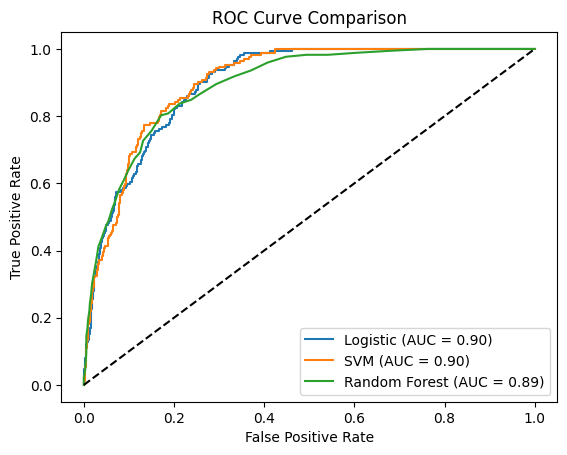

In [ ]:
plt.figure()

for name, (fpr, tpr, auc) in roc_results_tuned.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()